# 05 — Data Loading and Training with PyTorch

This notebook teaches how real PyTorch projects load data and train models using:

- `Dataset`
- `TensorDataset`
- Custom `Dataset`
- `DataLoader`
- Mini-batches
- Train / validation / test splits
- Reproducibility
- Training and validation loops
- Evaluation metrics
- A complete MLP classification pipeline

### Prerequisites
You should already understand tensors, autograd, `nn.Module`, layers, losses, optimizers, and the basic PyTorch training loop.

## Learning Objectives

By the end you should be able to:

1. Explain why `Dataset` and `DataLoader` are useful.
2. Create datasets with `TensorDataset`.
3. Build a custom `Dataset`.
4. Understand `__len__()` and `__getitem__()`.
5. Create mini-batches with `DataLoader`.
6. Understand `batch_size`, `shuffle`, `drop_last`, and `num_workers`.
7. Split data into train, validation, and test sets.
8. Write reusable training and validation loops.
9. Train a model using batches.
10. Evaluate a trained model on unseen data.

# 1. Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.9.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


# 2. Why Do We Need Dataset and DataLoader?

Imagine 100,000 training examples. Instead of sending all of them through the network at once, we normally divide them into mini-batches.

```text
100,000 samples
       ↓
Batch 1 → 64 samples
Batch 2 → 64 samples
Batch 3 → 64 samples
...
```

A `Dataset` answers: **How can I access one sample?**

A `DataLoader` answers: **How should I give those samples to the model in batches?**

# 3. TensorDataset

`TensorDataset` is convenient when your data is already stored in tensors.

In [2]:
X = torch.tensor([
    [1.0, 2.0],
    [2.0, 3.0],
    [3.0, 4.0],
    [4.0, 5.0],
    [5.0, 6.0]
])
y = torch.tensor([0, 0, 1, 1, 1])

dataset = TensorDataset(X, y)

print("Dataset size:", len(dataset))
print("First sample:", dataset[0])
print("Third sample:", dataset[2])

Dataset size: 5
First sample: (tensor([1., 2.]), tensor(0))
Third sample: (tensor([3., 4.]), tensor(1))


`TensorDataset(X, y)` pairs corresponding rows:

```text
X[0] ↔ y[0]
X[1] ↔ y[1]
...
```

So `dataset[0]` returns `(X[0], y[0])`.

# 4. DataLoader

A DataLoader takes samples from the dataset and groups them into batches.

In [3]:
loader = DataLoader(dataset, batch_size=2, shuffle=False)

for batch_X, batch_y in loader:
    print("X batch:")
    print(batch_X)
    print("y batch:")
    print(batch_y)
    print("---")

X batch:
tensor([[1., 2.],
        [2., 3.]])
y batch:
tensor([0, 0])
---
X batch:
tensor([[3., 4.],
        [4., 5.]])
y batch:
tensor([1, 1])
---
X batch:
tensor([[5., 6.]])
y batch:
tensor([1])
---


## Batch Size

With `batch_size=2` and 5 samples:

```text
Batch 1 → 2 samples
Batch 2 → 2 samples
Batch 3 → 1 sample
```

The batch size controls how many samples are processed before an optimizer update.

# 5. `shuffle=True`

During training we usually shuffle the training data so batches do not repeatedly contain samples in the original ordering.

In [4]:
loader = DataLoader(dataset, batch_size=2, shuffle=True)

for batch_X, batch_y in loader:
    print(batch_y)

tensor([1, 1])
tensor([1, 0])
tensor([0])


A common setup is:

```python
train_loader = DataLoader(train_dataset, shuffle=True)
val_loader = DataLoader(val_dataset, shuffle=False)
test_loader = DataLoader(test_dataset, shuffle=False)
```

# 6. Creating a Custom Dataset

A PyTorch `Dataset` fundamentally provides:

- `__len__()` → number of samples
- `__getitem__(index)` → one sample

This becomes useful for CSV files, images, text, databases, sensor data, and custom formats.

In [5]:
class SimpleDataset(Dataset):
    def __init__(self):
        self.X = torch.tensor([
            [1.0, 2.0],
            [2.0, 3.0],
            [3.0, 4.0],
            [4.0, 5.0]
        ])
        self.y = torch.tensor([0, 0, 1, 1])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

custom_dataset = SimpleDataset()

print("Number of samples:", len(custom_dataset))
print("Sample 0:", custom_dataset[0])
print("Sample 3:", custom_dataset[3])

Number of samples: 4
Sample 0: (tensor([1., 2.]), tensor(0))
Sample 3: (tensor([4., 5.]), tensor(1))


## Dataset Flow

```text
DataLoader
    ↓
dataset[5]
    ↓
__getitem__(5)
    ↓
(X[5], y[5])
```

The model does not need to know where the data came from.

# 7. Custom Dataset with NumPy Data

In [6]:
class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

X_np = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
y_np = np.array([0, 0, 1, 1])

dataset = NumpyDataset(X_np, y_np)
print(dataset[0])

(tensor([1., 2.]), tensor(0))


# 8. Important DataLoader Parameters

```python
DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=False,
    pin_memory=False
)
```

- `batch_size`: samples per batch.
- `shuffle`: randomize order.
- `num_workers`: worker processes used to load data. `0` is a safe starting point on Windows.
- `drop_last`: discard an incomplete final batch.
- `pin_memory`: can improve CPU→GPU transfers in suitable CUDA workloads.

# 9. `drop_last`

With 10 samples and `batch_size=4`, keeping the last batch gives `4, 4, 2`. With `drop_last=True`, it gives `4, 4`.

In [7]:
small_dataset = TensorDataset(
    torch.arange(10).float().reshape(-1, 1),
    torch.arange(10)
)

loader_keep = DataLoader(small_dataset, batch_size=4, drop_last=False)
loader_drop = DataLoader(small_dataset, batch_size=4, drop_last=True)

print("Without drop_last:")
for X_batch, y_batch in loader_keep:
    print(len(X_batch))

print("\nWith drop_last=True:")
for X_batch, y_batch in loader_drop:
    print(len(X_batch))

Without drop_last:
4
4
2

With drop_last=True:
4
4


# 10. Epochs and Batches

If we have 1000 samples and `batch_size=100`:

```text
1000 / 100 = 10 batches per epoch
```

One **epoch** means the model has processed the entire training dataset once.

Normally one optimizer update occurs per batch.

# 11. Train / Validation / Test Sets

A common split is:

```text
Dataset
   ├── Train       → update parameters
   ├── Validation  → monitor development
   └── Test        → final evaluation
```

For example: 70% / 15% / 15%.

# 12. `random_split`

PyTorch provides `random_split()` for simple random partitioning.

In [8]:
full_dataset = TensorDataset(
    torch.randn(100, 4),
    torch.randint(0, 3, (100,))
)

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [70, 15, 15],
    generator=generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 70
Validation: 15
Test: 15


## Reproducibility

Using:

```python
torch.Generator().manual_seed(42)
```

makes the random split reproducible for the same inputs and environment.

# 13. DataLoaders for Each Split

In [9]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 5
Validation batches: 1
Test batches: 1


# 14. Synthetic 3-Class Classification Dataset

We will create three classes in a 2D feature space.

In [10]:
torch.manual_seed(42)

n_per_class = 500

class_0 = torch.randn(n_per_class, 2) * 0.8 + torch.tensor([-2.0, -2.0])
class_1 = torch.randn(n_per_class, 2) * 0.8 + torch.tensor([2.0, -2.0])
class_2 = torch.randn(n_per_class, 2) * 0.8 + torch.tensor([0.0, 2.0])

X = torch.cat([class_0, class_1, class_2])
y = torch.cat([
    torch.zeros(n_per_class, dtype=torch.long),
    torch.ones(n_per_class, dtype=torch.long),
    torch.full((n_per_class,), 2, dtype=torch.long)
])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([1500, 2])
y shape: torch.Size([1500])


# 15. Visualize the Dataset

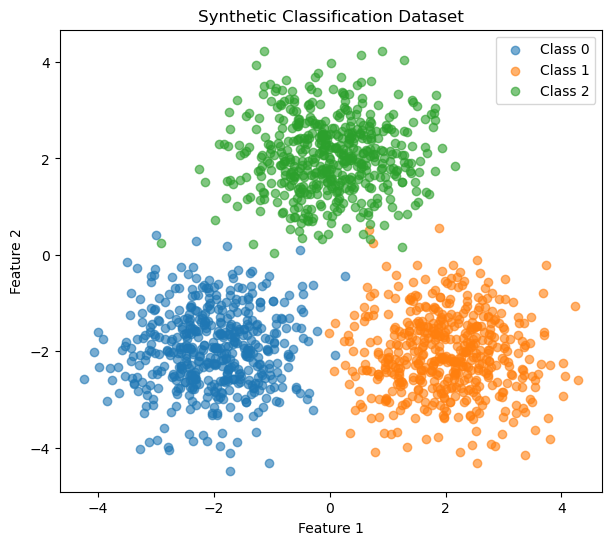

In [11]:
plt.figure(figsize=(7, 6))

for class_id in range(3):
    mask = y == class_id
    plt.scatter(X[mask, 0], X[mask, 1], alpha=0.6, label=f"Class {class_id}")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Classification Dataset")
plt.legend()
plt.show()

# 16. Split the Dataset

In [12]:
dataset = TensorDataset(X, y)

train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1050
Validation: 225
Test: 225


# 17. Create DataLoaders

In [13]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X_batch, y_batch = next(iter(train_loader))

print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)

Batch X shape: torch.Size([32, 2])
Batch y shape: torch.Size([32])


For this dataset:

```text
X batch → [32, 2]
y batch → [32]
```

The first dimension is the number of samples in the batch.

# 18. Build the Neural Network

Architecture:

```text
2 features
   ↓
Linear(2 → 32)
   ↓
ReLU
   ↓
Linear(32 → 16)
   ↓
ReLU
   ↓
Linear(16 → 3)
   ↓
Logits
```

In [14]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

model = Classifier()
print(model)

Classifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)


# 19. Loss Function and Optimizer

For 3-class classification use `CrossEntropyLoss`.

The model outputs raw logits, so **do not add Softmax before `CrossEntropyLoss`**.

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# 20. Training One Epoch

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total

# 21. Validation / Evaluation Function

In [17]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = logits.argmax(dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total

# 22. Select CPU or GPU

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Using device:", device)

Using device: cuda


# 23. Full Training Loop

The important sequence is:

```text
Get batch
   ↓
Forward
   ↓
Loss
   ↓
zero_grad
   ↓
Backward
   ↓
Optimizer step
```

In [19]:
num_epochs = 30

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/30 | Train Loss: 0.9445 | Train Acc: 0.7152 | Val Loss: 0.8425 | Val Acc: 0.9778
Epoch 02/30 | Train Loss: 0.6942 | Train Acc: 0.9848 | Val Loss: 0.6173 | Val Acc: 0.9911
Epoch 03/30 | Train Loss: 0.4710 | Train Acc: 0.9867 | Val Loss: 0.4017 | Val Acc: 0.9956
Epoch 04/30 | Train Loss: 0.2885 | Train Acc: 0.9914 | Val Loss: 0.2339 | Val Acc: 1.0000
Epoch 05/30 | Train Loss: 0.1681 | Train Acc: 0.9943 | Val Loss: 0.1310 | Val Acc: 1.0000
Epoch 06/30 | Train Loss: 0.1011 | Train Acc: 0.9952 | Val Loss: 0.0760 | Val Acc: 1.0000
Epoch 07/30 | Train Loss: 0.0661 | Train Acc: 0.9952 | Val Loss: 0.0484 | Val Acc: 1.0000
Epoch 08/30 | Train Loss: 0.0479 | Train Acc: 0.9943 | Val Loss: 0.0342 | Val Acc: 1.0000
Epoch 09/30 | Train Loss: 0.0379 | Train Acc: 0.9943 | Val Loss: 0.0256 | Val Acc: 1.0000
Epoch 10/30 | Train Loss: 0.0315 | Train Acc: 0.9943 | Val Loss: 0.0200 | Val Acc: 1.0000
Epoch 11/30 | Train Loss: 0.0274 | Train Acc: 0.9952 | Val Loss: 0.0163 | Val Acc: 1.0000
Epoch 12/3

# 24. Plot Loss

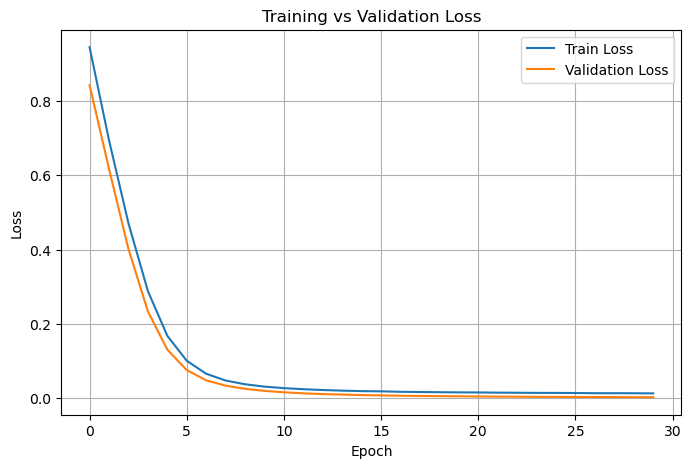

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 25. Plot Accuracy

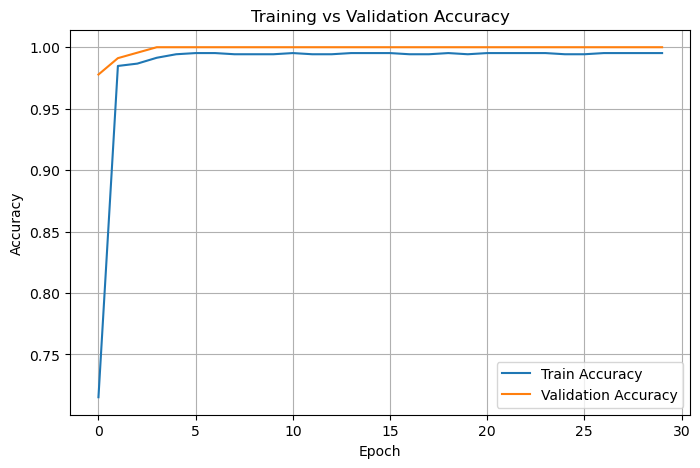

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 26. Final Test Evaluation

In [22]:
test_loss, test_acc = evaluate(
    model, test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0303
Test Accuracy: 0.9778


# 27. Making Predictions

In [23]:
model.eval()

X_test_batch, y_test_batch = next(iter(test_loader))
X_test_batch = X_test_batch.to(device)
y_test_batch = y_test_batch.to(device)

with torch.no_grad():
    logits = model(X_test_batch)
    probabilities = torch.softmax(logits, dim=1)
    predictions = logits.argmax(dim=1)

print("True labels:     ", y_test_batch[:10].cpu().numpy())
print("Predicted labels:", predictions[:10].cpu().numpy())
print("Probabilities:")
print(probabilities[:3].cpu())

True labels:      [2 0 0 0 0 1 2 1 1 1]
Predicted labels: [2 0 0 0 0 1 2 1 1 1]
Probabilities:
tensor([[5.1275e-06, 1.5542e-05, 9.9998e-01],
        [9.9971e-01, 3.2258e-05, 2.5927e-04],
        [9.9995e-01, 3.2786e-06, 4.3247e-05]])


### Logits vs Probabilities

Training:

```python
loss = CrossEntropyLoss()(logits, y)
```

For displaying probabilities:

```python
probabilities = torch.softmax(logits, dim=1)
```

Softmax is useful for interpretation, but is not needed before `CrossEntropyLoss`.

# 28. `model.train()` vs `model.eval()`

Use:

```python
model.train()
```

during training.

Use:

```python
model.eval()
```

during validation/testing.

This matters especially for layers such as Dropout and BatchNorm.

# 29. Why `torch.no_grad()` During Evaluation?

During evaluation we do not need gradients:

```python
with torch.no_grad():
    output = model(X)
```

This reduces unnecessary gradient tracking, memory usage, and computation.

# 30. `num_workers` on Windows

You may see:

```python
DataLoader(dataset, batch_size=32, num_workers=4)
```

Multiple workers can speed up loading large datasets. For simple notebooks on Windows, start with:

```python
num_workers=0
```

Increase it only when you understand the multiprocessing setup and need the performance.

# 31. `pin_memory` and CUDA

For suitable GPU workloads:

```python
DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    pin_memory=True
)
```

and:

```python
X = X.to(device, non_blocking=True)
```

Pinned memory can improve CPU→GPU transfer efficiency, although the benefit may be small for tiny datasets.

# 32. Common Tensor Shapes

### Tabular

```text
X = [batch_size, features]
```

Example: `[32, 10]`

### Image

```text
X = [batch_size, channels, height, width]
```

Example: `[32, 3, 224, 224]`

### Sequence

Often:

```text
X = [batch_size, sequence_length, features]
```

The exact convention depends on the model/API.

# 33. Common Mistake: Target Type

For multiclass classification with:

```python
nn.CrossEntropyLoss()
```

targets normally need integer class indices:

```python
torch.long
```

Example:

```python
y = torch.tensor([0, 2, 1], dtype=torch.long)
```

# 34. Common Mistake: Output and Target Shapes

For 3 classes and batch size 32:

```text
logits → [32, 3]
target → [32]
```

The 3 output values are the class logits for each sample.

# 35. Common Mistake: Data Leakage

Never use information from the test set to tune your model.

A clean workflow is:

```text
Train → learn parameters
Validation → make development decisions
Test → final evaluation
```

The test set should remain untouched until the final evaluation.

# 36. Complete PyTorch Data Pipeline

```text
Raw Data
   ↓
Dataset
   ↓
DataLoader
   ↓
Mini-batch
   ↓
Model
   ↓
Logits
   ↓
Loss
   ↓
Backward
   ↓
Optimizer
   ↓
Updated Parameters
   ↓
Next Batch
```

# 37. Knowledge Check

1. What is the difference between a `Dataset` and a `DataLoader`?
2. What does `__getitem__()` do?
3. Why do we use `batch_size`?
4. Why is `shuffle=True` commonly used for training?
5. Why is `shuffle=False` normally used for validation/test?
6. What does one epoch mean?
7. What is `random_split()` used for?
8. Why call `model.eval()` during evaluation?
9. Why use `torch.no_grad()` during evaluation?
10. For 3-class classification with `CrossEntropyLoss`, what should the model output and target shapes be for a batch of 32?

# 38. Key Takeaways

### Dataset

```python
dataset[index]
```

gives one sample.

### DataLoader

```python
DataLoader(dataset, batch_size=32)
```

creates mini-batches.

### Training

```python
model.train()
optimizer.zero_grad()
output = model(X)
loss = criterion(output, y)
loss.backward()
optimizer.step()
```

### Evaluation

```python
model.eval()
with torch.no_grad():
    output = model(X)
```

### Typical split

```text
Train → update parameters
Validation → monitor development
Test → final evaluation
```